* ## Angélica Vanegas C.C 1000290572

In [1]:
#Librery
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt

In [2]:
#up files from Drive
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')
#Read
path = 'drive/MyDrive/Fis_Comp_I/PDE/figures/'
filename3 = 'Laplace_df_3.png'
filename2 = 'Laplace_df_2.png'
filename4 = 'Laplace_df_4.png'

Mounted at /content/drive


# Finite-difference method

In general to solve a PDE, we divide the space up into a **laticce** an solve the field $u(\vec{r})$ at each site of the lattie. We will express derivatives in terms od finite differences in the values of $u$ at the laticce sites.

To derive the algorith we will use the Poisson and Laplace's equation as an example. We star by adding the Taylor expansions for $u(x,y)$:

* Derivate to the right:
\begin{align}
u(x+\Delta x,y) = u(x,y) + \dfrac{\partial u}{\partial x}\Delta x + \dfrac{1\partial^2 u}{2\partial x^2}(\Delta x)^2 + \cdots
\end{align}
* Derivate to the left:
\begin{align}
u(x-\Delta x,y) = u(x,y) - \dfrac{\partial u}{\partial x}\Delta x + \dfrac{1\partial^2 u}{2\partial x^2}(\Delta x)^2 - \cdots\,.
\end{align}

If we add this expressions the odd term cancel up. Notice that we eliminated the firts derivative of the field.

\begin{align}
\dfrac{\partial^2 u(x,y)}{\partial x^2}\approx \dfrac{u(x+\Delta x,y)+u(x-\Delta x,y)-2u(x,y)}{(\Delta x)^2}\,,
\end{align}
similarly foy $y$ variable
\begin{align}
\dfrac{\partial^2 u(x,y)}{\partial y^2}\approx \dfrac{u(x, y+\Delta y)+u(x,y-\Delta y)-2u(x,y)}{(\Delta y)^2}\,,
\end{align}

## 1. Poisson and Laplace's equation

The Poisson's equation is:
\begin{align}
\boxed{
\dfrac{\partial^2 u(x,y)}{\partial x^2}+\dfrac{\partial^2 u(x,y)}{\partial y^2} = -4\pi\rho(x,y)} \,,
\end{align}
let's expresed in finite diferences.

\begin{align}
\dfrac{\partial^2 u(x,y)}{\partial x^2}+\dfrac{\partial^2 u(x,y)}{\partial y^2} \approx& \dfrac{u(x+\Delta x,y)+u(x-\Delta x,y)-2u(x,y)}{(\Delta x)^2} +  \dfrac{u(x, y+\Delta y)+u(x,y-\Delta y)-2u(x,y)}{(\Delta y)^2}\\ \approx& -4\pi\rho(x,y) \,.
\end{align}

If we assume equal spacing in the grid $\Delta x = \Delta y =\Delta$, the algorithm takes a simple form:

\begin{align}
u(x+\Delta,y)+u(x-\Delta,y) +
u(x, y+\Delta)+u(x,y-\Delta)-4u(x,y) = -4\pi\rho(x,y)\Delta^2 \,.
\end{align}

To ilustrate the method we will use the Laplace's equation in the contxt of the electric potential $u(x,y)$ ($\rho\to 0$). The elctric charge, which are the souce of fields, enters indirectly in values of the electric potential in some regions of space. Let's consider the grid:



A survey of Computational physics (Manuel Paez book)


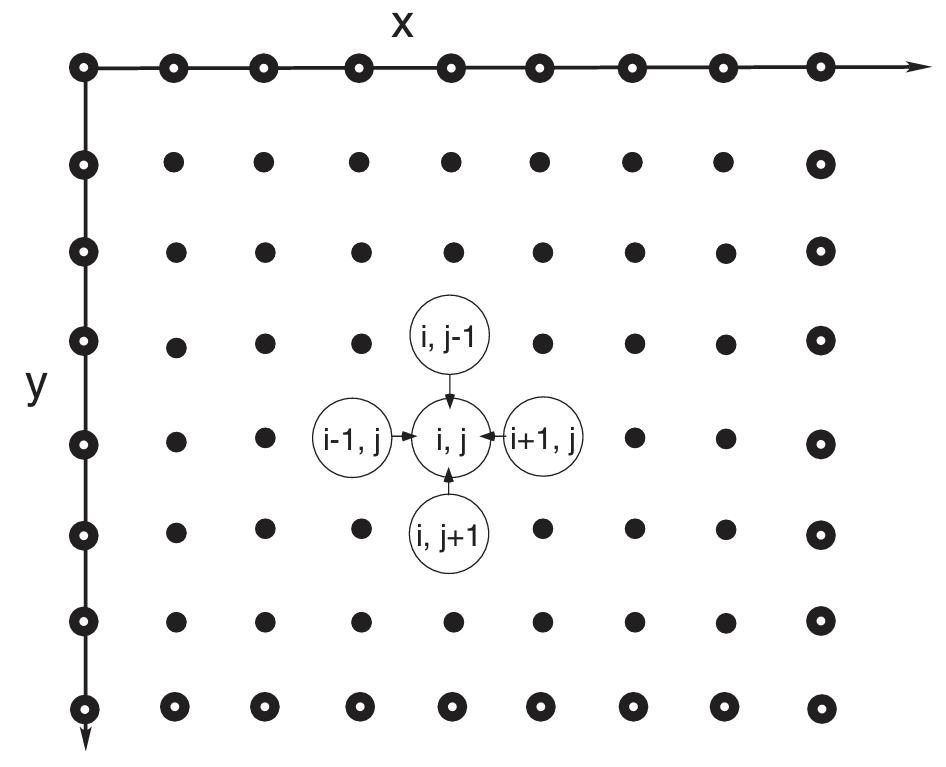

In [ ]:
print('A survey of Computational physics (Manuel Paez book)')
from IPython.display import Image
Image(filename=path+filename3, width=400)

To simplifie the notation and to use a compact and discrete notation, let's be: $x_i=x_0+i\Delta$, $y_j=y_0+j\Delta$, $\{i,j\}=0,\cdots N$. The latter Laplace's equation can be writeen as:

\begin{align}
u(x,y) = \dfrac{1}{4} \left( u(x+\Delta,y)+u(x-\Delta,y) +
u(x, y+\Delta)+u(x,y-\Delta)\right)\,.
\end{align}
In terms of finite differences:
\begin{align}
\boxed{
u_{i,j} = \dfrac{1}{4} \big[ u_{i+1,j}+u_{i-1,j} +
u_{i,j+1}+u_{i,j-1} \big]}\,
\end{align}

This equation expresed the Laplace's equation. It says that the solution at the site $(i,j)$ is the average of the potential at four nearest neighbors as is shown in last figure, $u_{i,j}=u(x_i,y_j)$. We must star  with a initian condition (guest) to the potential, improved it by sweeping through all space taking acount the nearest neighbors at each nodo in the grid. Repeat the process until the solution not longer change to some level of precision (tolerance) or failure.

Does it always converge? how fast?... we will se latter. The relaxation methods converge slowly, although still faster than a Fourier series (Paez, Landau).

## Relaxation

The basic form to interated the last equation is the **Jacobi method** in which the potential values are not change until an entire sweep of applying the last equation to each point is completed.

To accelerated the convergence, which in tirn leads to less round-off error, we can use the technique,knows as **Gauss-Seidel (GS) method**. In terms of finite differences (see references):

\begin{align}
u_{i,j}^{\text{new}} = \dfrac{1}{4} \big[ u_{i+1,j}^{\text{old}}+u_{i-i,j}^{\text{new}} +
u_{i,j+1}^{\text{old}}+u_{i,j-1}^{\text{new}} \big]\,.
\end{align}

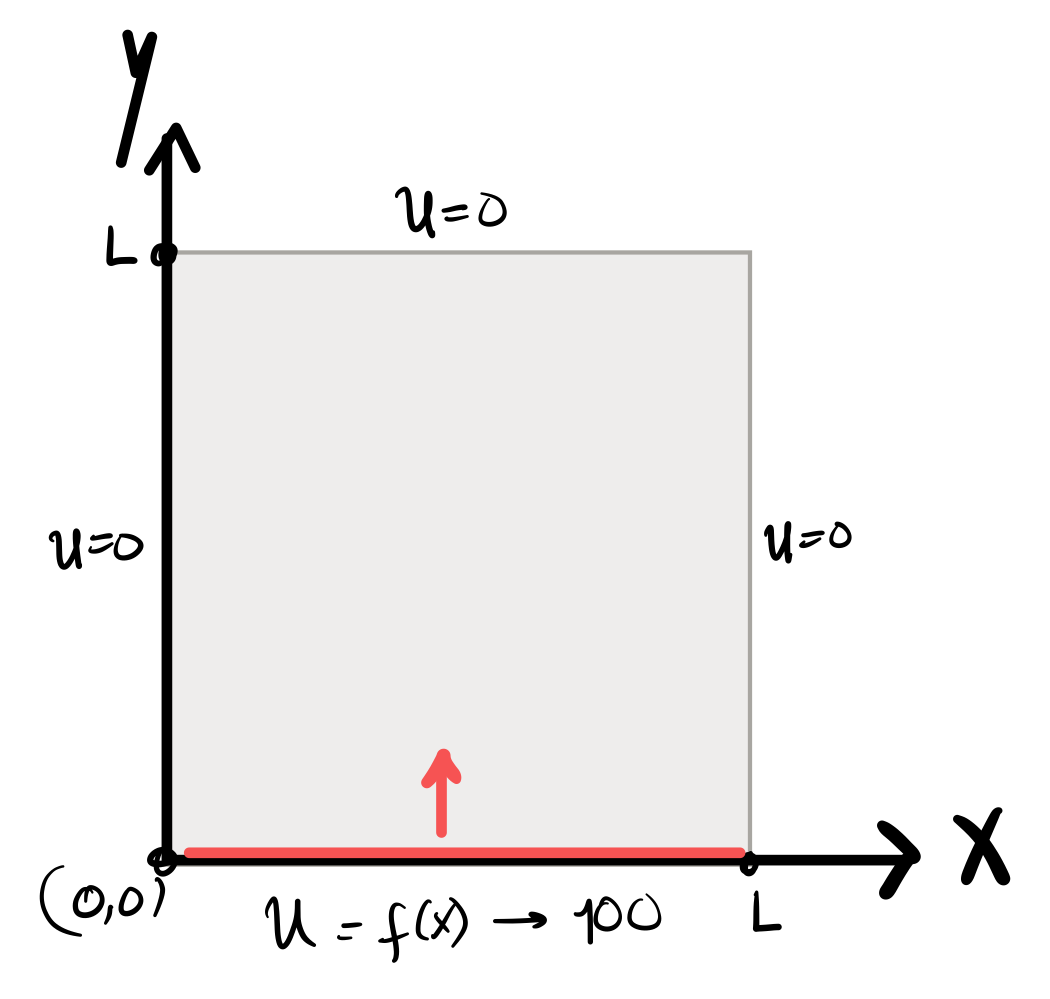

In [ ]:
from IPython.display import Image
Image(filename=path+filename2, width=300)

### Example 1: Solve the Laplace's equation
Let's use the **Jacobi method** to solve the **Laplace's equation** in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x)-> $V_0=$100V
* u(0,y)=0
* u(L,y)=0
* u(x,L)=0

Not continuous in the corners (y=0,L).

To solve the Laplace's equation we set the lenght plate $L=N\Delta = 100$ and $\Delta=1$. Also, we interact the algorithm $N_\text{iter}$ times.
 \begin{align}
 u(i,N) =\, & 99\,, \text{bottom} \hspace{1 cm} u(0,j) =\,0\,, \text{left} \\
 u(N,j) =\, & 0\,, \text{right} \hspace{1.7 cm} u(i,0) =\,0\,, \text{top}\,.
 \end{align}

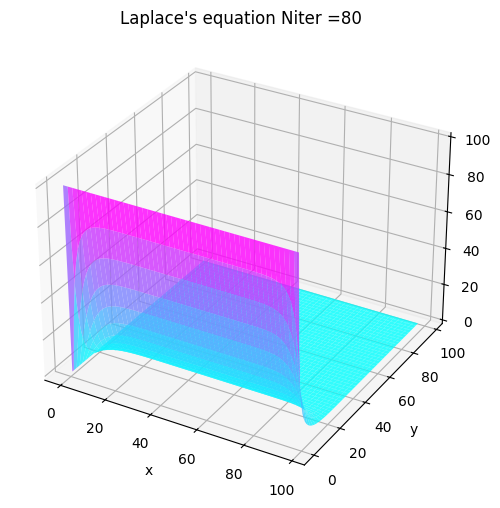

In [3]:
Nmax, Niter = 100, 80  #longitud de la malla, iteraciones

V = np.zeros((Nmax, Nmax), float) #arreglo de ceros de acuerdo a las dimensiones de la malla

for k in range(0, Nmax):    #define la condicion de frontera, en y=0 el valor de la funcion es 100 para cada x
  V[k,0] = 100.0

for iter in range(Niter):   #método iterativo
  for i in range(1, Nmax-1):
    for j in range(1,Nmax-1):
      V[i,j] = 0.25*(V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1])


x = np.arange(0, Nmax-1, 1) #crea la malla a graficar
y = x
X, Y = np.meshgrid(x,y)

def functz(V,X,Y): # Function returns V(x, y)
  z = V[X,Y]
  return z

Z = functz(V,X,Y)

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)

ax.set_title('Laplace\'s equation Niter =%.1d'%Niter)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

### Laplace 2D general rutine

In [4]:
#****** LaplaceLine.py in Paez, *************************************
#       Computational physics with python- Manuel Paez, Landau book.
#********************************************************************
def Laplace2D(V_ini,Niter,x,y):
  '''Int the V initial configutaration.\n Niter is the number of the itertions of the algorithm.
  x(y) the array in x(y) variable.
  Return X,Y,Z evolve Niter times using finite differences for the Laplace case.'''

  Nmax = V_ini.shape[0]
  V = V_ini.copy()

  for iter in range(Niter): # iterations over algorithm. Niter times
    for i in range(1, Nmax-1):
      for j in range(1,Nmax-1):
        V[i,j] = 0.25*(V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1])

  X, Y = np.meshgrid(x,y)

  Z = V[X,Y] #filed value
  #retunr grid
  return X,Y,Z

Let's do the example again (using the rutine):

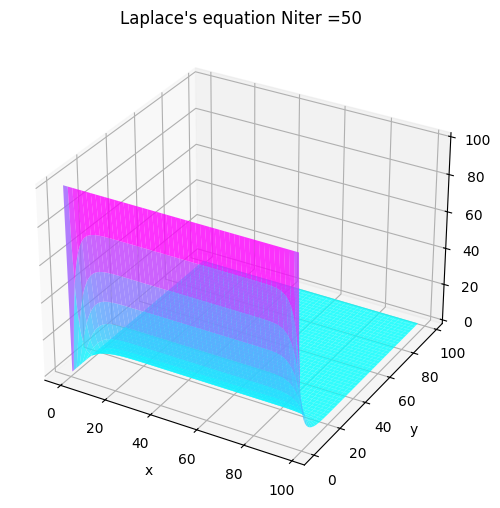

In [5]:
Nmax, Niter = 100, 50

#Initial V matrix
V_ini = np.zeros((Nmax, Nmax), float) # grid in 0V.
for k in range(0, Nmax):
  V_ini[k,0] = 100.0 # let line at 100V

#Do the grid to plot
x = np.arange(0, Nmax-1, 1)
y = x
#Run Laplace2D rutine
X = Laplace2D(V_ini, Niter,x,y)[0]
Y = Laplace2D(V_ini, Niter,x,y)[1]
Z = Laplace2D(V_ini, Niter,x,y)[2]

#Plot the field
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax.set_title('Laplace\'s equation Niter =%.1d'%Niter)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

Behaviour with the number of iteration of the algoritm.

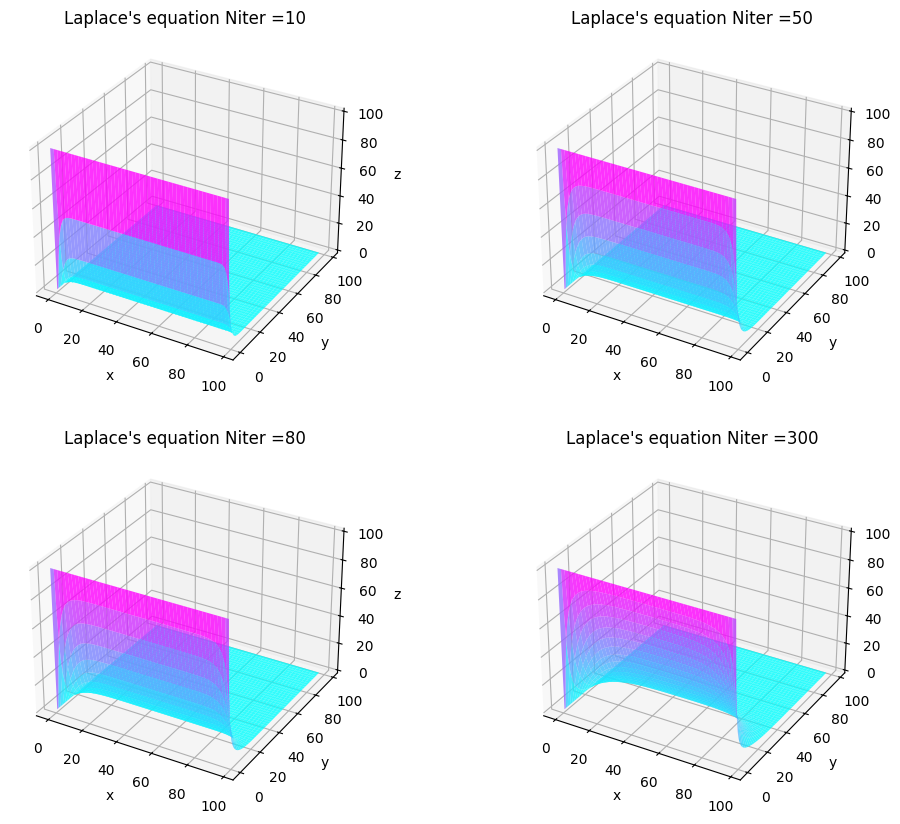

In [6]:
fig, ax= plt.subplots(2,2, subplot_kw={'projection': '3d'},figsize=(12,10))
#************************************
Nmax, Niter = 100, 10
#Run Laplace2D rutine
X = Laplace2D(V_ini, Niter,x,y)[0]
Y = Laplace2D(V_ini, Niter,x,y)[1]
Z = Laplace2D(V_ini, Niter,x,y)[2]
#Plot the field
ax[0,0].plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax[0,0].set_title('Laplace\'s equation Niter =%.1d'%Niter)
ax[0,0].set_xlabel('x')
ax[0,0].set_ylabel('y')
ax[0,0].set_zlabel('z')
#************************************
Nmax, Niter = 100, 50
#Run Laplace2D rutine
X = Laplace2D(V_ini, Niter,x,y)[0]
Y = Laplace2D(V_ini, Niter,x,y)[1]
Z = Laplace2D(V_ini, Niter,x,y)[2]
#Plot the field
ax[0,1].plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax[0,1].set_title('Laplace\'s equation Niter =%.1d'%Niter)
ax[0,1].set_xlabel('x')
ax[0,1].set_ylabel('y')
ax[0,1].set_zlabel('z')
#************************************
Nmax, Niter = 100, 80
#Run Laplace2D rutine
X = Laplace2D(V_ini, Niter,x,y)[0]
Y = Laplace2D(V_ini, Niter,x,y)[1]
Z = Laplace2D(V_ini, Niter,x,y)[2]
#Plot the field
ax[1,0].plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax[1,0].set_title('Laplace\'s equation Niter =%.1d'%Niter)
ax[1,0].set_xlabel('x')
ax[1,0].set_ylabel('y')
ax[1,0].set_zlabel('z')
#************************************
Nmax, Niter = 100, 300
#Run Laplace2D rutine
X = Laplace2D(V_ini, Niter,x,y)[0]
Y = Laplace2D(V_ini, Niter,x,y)[1]
Z = Laplace2D(V_ini, Niter,x,y)[2]
#Plot the field
ax[1,1].plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax[1,1].set_title('Laplace\'s equation Niter =%.1d'%Niter)
ax[1,1].set_xlabel('x')
ax[1,1].set_ylabel('y')
ax[1,1].set_zlabel('z')
#************************************

plt.show()

#### Exercise 1: Lab1_3: finite-differences with tolerance

* Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$).
* Do a plot of the field $u(x,y)$ for a tolerance of $\text{tol}=10^{-3}$. Explaint in words the strategy.
* Compare with Fourier serie. How many terms in the fourier serie are necesary to obtaind a $\text{tol}=10^{-3}$.

# Solución



Lo que queremos definir es que el valor de la malla en una iteración y en la siguiente sea menor al valor dado por la tolerancia, es decir, la diferencia de los valores en la malla la llamaremos "error" y ese error es el que se compara con la tolerancia.

$error = max |V^{n+1} - V^{n} | < tolerancia$

Vamos a hallar esto para el valor de Z en la función y luego con el valor $Niter$ que hallemos graficaremos la función.

In [63]:
tolerancia = 0.1 #vamos a definir un valor de tolerancia, en este caso el más pequeño del rango por cuestión de tiempo de ejecución
error = 1
N_iter = 1                                                            #empezamos con una iteracción

while error > tolerancia:                                             #se repide hasta que se alcance la tolerancia deseada
  Z_old = Laplace2D(V_ini, N_iter, x, y)[2]
  Z_new = Laplace2D(V_ini, N_iter + 1, x, y)[2]

  error_ = np.max(np.abs(Z_new - Z_old))                              #número que más cambió en la malla, el error es el valor absoluto de esa diferencia
  error = error_                                                      #se redefine para que el ciclo continúe
  N_iter += 1                                                         #se redefinen se suma un valor a la iteración


print(N_iter)                                                         #número final de iteraciones

235


### El número que nos devuelve el código es $Niter = 235$. Para hallar ese valor el código se demoró 6 min aproximadamente en ejecución. En los primeros valores de la iteracion el error decrece bastante rápido, el número inicial es de 14 aprox y rápidamente llega a un error de 2, sin embargo para llegar a 0.1 se demora la mayor cantidad de iteraciones.

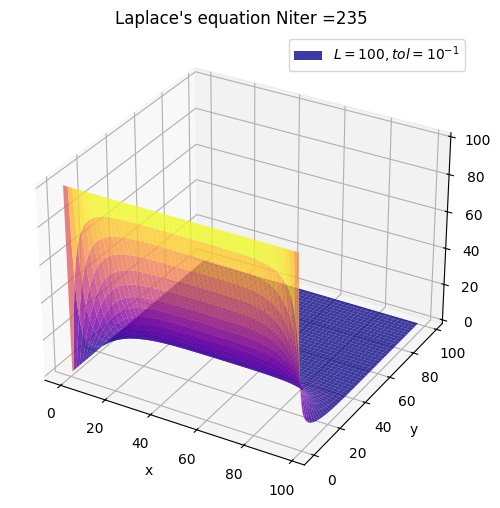

In [75]:
#@title Grafiquita

Nmax, Niter = 100, 235

V_ini = np.zeros((Nmax, Nmax), float)
for k in range(0, Nmax):
  V_ini[k,0] = 100.0

x = np.arange(0, Nmax-1, 1)
y = x

X = Laplace2D(V_ini, Niter,x,y)[0]
Y = Laplace2D(V_ini, Niter,x,y)[1]
Z = Laplace2D(V_ini, Niter,x,y)[2]


fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='plasma', alpha=0.8, label = "$L = 100, tol= 10^{-1}$")
ax.set_title('Laplace\'s equation Niter =%.1d'%Niter)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.legend()
plt.show()

### Como ya se vió que el código es muy ineficiente lo que vamos a hacer es reducir el tamaño de la malla para que se recorran en menos tiempo.

In [77]:
#@title Calculo de iteraciones con una malla más pequeña.

Nmax = 20
V_ = np.zeros((Nmax, Nmax), float)   #redefinimos la malla
for k in range(0, Nmax):
  V_[k,0] = 100.0 # let line at 100V
x = np.arange(0, (Nmax)-1, 1)
y = x

tolerancia2 = 0.001
error2 = 1
N_iter2 = 1

while error2 > tolerancia2:
  Z_old = Laplace2D(V_, N_iter2, x, y)[2]
  Z_new = Laplace2D(V_, N_iter2 + 1, x, y)[2]

  error_ = np.max(np.abs(Z_new - Z_old))
  error2 = error_
  N_iter2 += 1


print(N_iter2)

253


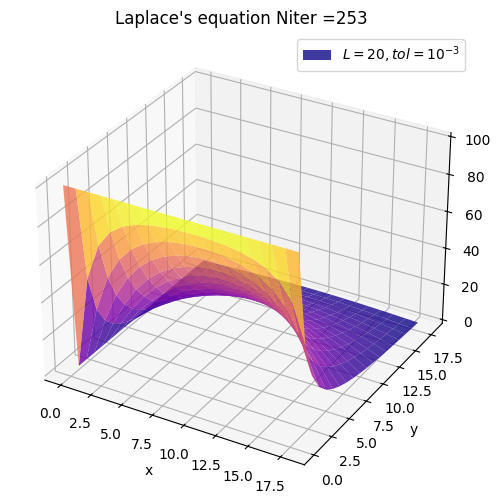

In [80]:
#@title Grafiquita

X = Laplace2D(V_, N_iter2 ,x,y)[0]
Y = Laplace2D(V_, N_iter2 ,x,y)[1]
Z = Laplace2D(V_, N_iter2 ,x,y)[2]

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='plasma', alpha=0.8, label = "$L = 20, tol = 10^{-3}$")
ax.set_title('Laplace\'s equation Niter =%.1d'%N_iter2)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.legend()
plt.show()

### La solución analítica para este caso es:

\begin{align}
u(x,y) = \sum_{n=impares}\frac{400}{n\pi sinh(n\pi)} sin(\frac{n\pi x}{L}) sinh(\frac{n\pi(L - y)}{L})
\end{align}

y tomaremos el mismo criterio $max = |u_{n+2} - u_{n}| < tol = 10^{-3}$

In [84]:
# Parámetros
L = 20
pasos = 50
tol = 1e-3

# Malla
x = np.linspace(0, L, pasos)
y = np.linspace(0, L, pasos)
X, Y = np.meshgrid(x, y)

# Serie de Fourier
def solucion_fourier(N):
    U = np.zeros_like(X)

    for n in range(1, N+1, 2):  # solo impares
        const = (400/(n*np.pi)) * (1/np.sinh(n*np.pi))

        U += const * np.sin(n*np.pi*X/L) * np.sinh(n*np.pi*(L-Y)/L)

    return U

# Encontrar número de términos en la sumatoria
error = 1
N = 1

while error > tol:
    U_old = solucion_fourier(N)
    U_new = solucion_fourier(N + 2)

    error = np.max(np.abs(U_new - U_old))

    N += 2

print("Términos necesarios:", N)

Términos necesarios: 49


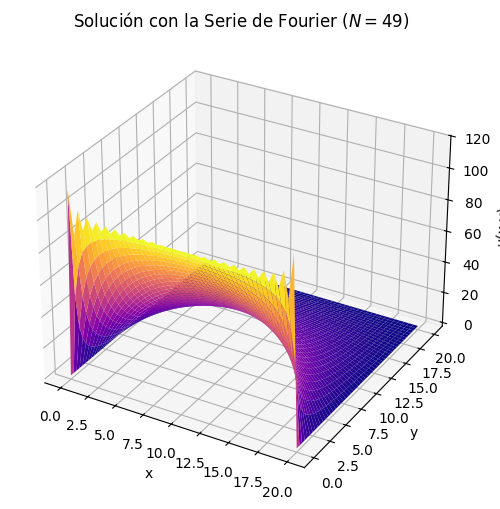

In [85]:
# Solución final
U = solucion_fourier(N)

fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection='3d')
surf = ax.plot_surface(X, Y, U, cmap="plasma")
ax.set_title(f"Solución con la Serie de Fourier ($N = {N}$)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("u(x,y)")
plt.show()

### Como se puede observar, si graficamos la forma analítica de la función, en la parte superior del eje Z nos logra graficar las oscilaciones de la funcion armónica que tenemos en este caso. Se puede concluir que es mucho mas eficiente este método.

#### Exercise 2: Lab1_4: finite-differences for oppen boundaries

Solve analytically and numerically the **Laplace's equation** for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x) = $u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* u(0,y)=0
* u(L,y)=0
* u(x,$\infty$)=0


To solve numerically the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

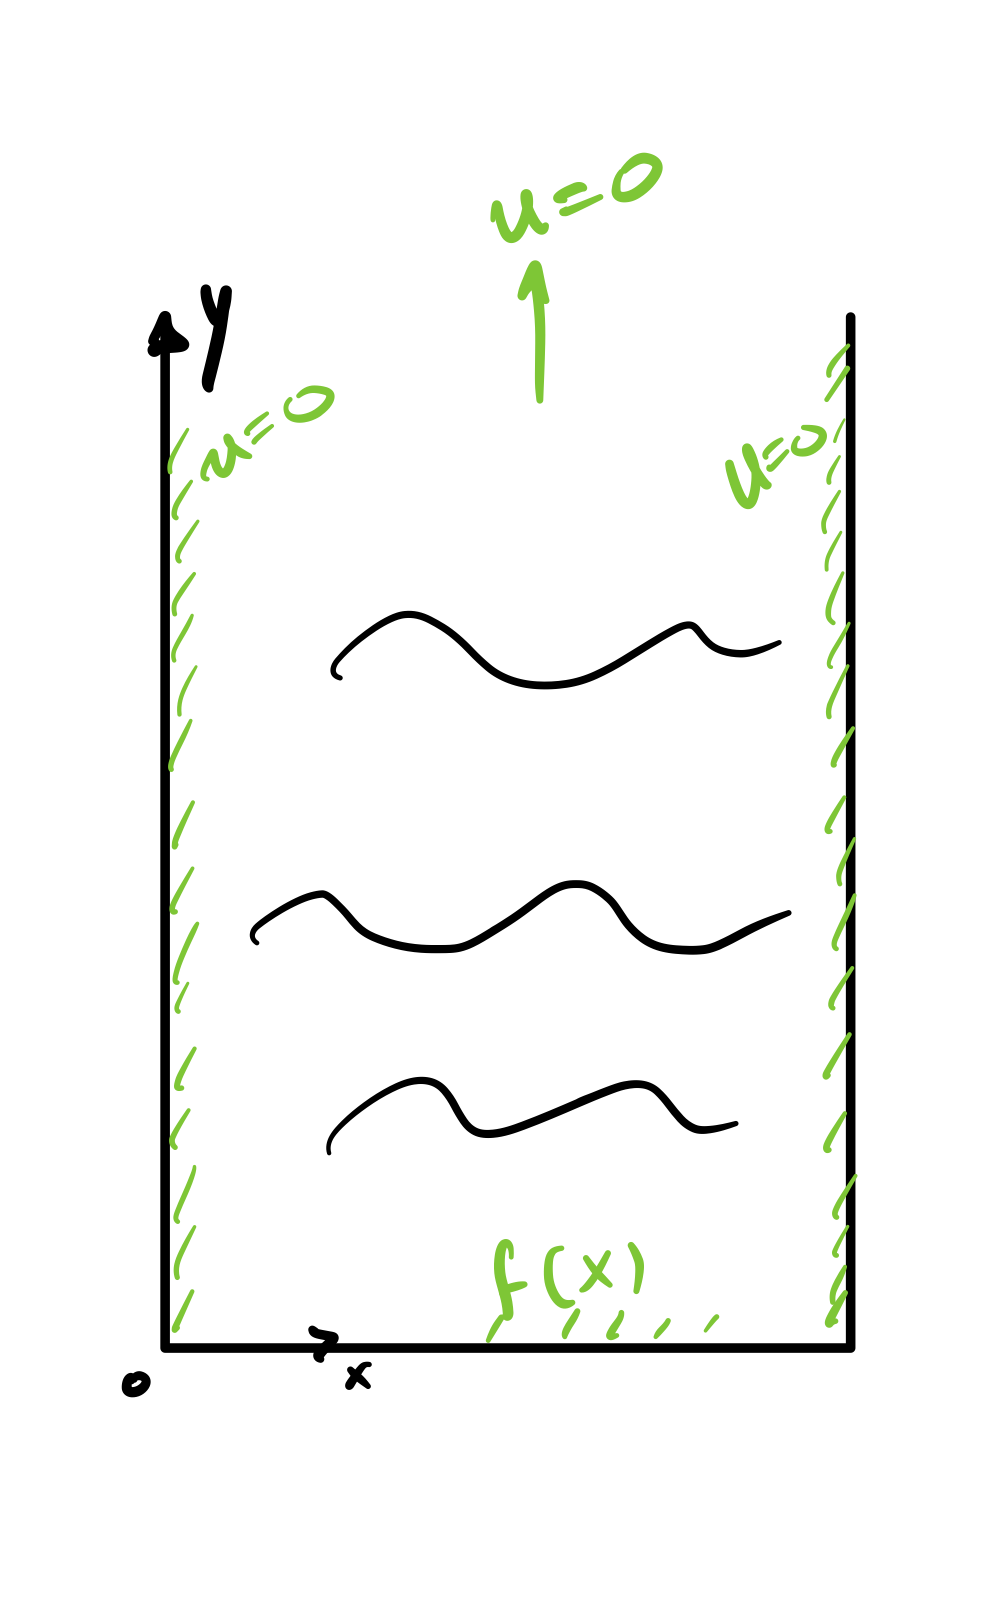

In [ ]:
from IPython.display import Image
Image(filename=path+filename4, width=200)

### La solución analítica es de la forma:

\begin{align}
u(x,0)=V(x)=f(x) = u_0\sin(2\pi x/L)e^{-2\pi y/L}
\end{align}



In [97]:
L = 100
u0 = 100
Nx = 100
Ny = 10000                                                         #se debe truncar en algún punto

x = np.linspace(0, L, Nx)                                          #creamos la malla
y = np.linspace(0, Ny, Ny)

X, Y = np.meshgrid(x, y)
U_exact = u0 * np.sin(2*np.pi*X/L) * np.exp(-2*np.pi*Y/L)          #solución de la función

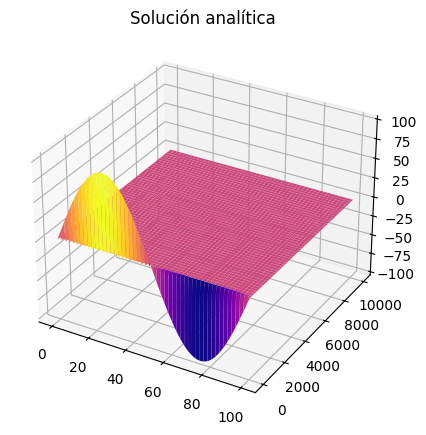

In [98]:
#@title Grafiquita de la solución analítica

fig = plt.figure(figsize=(12,5))
ax2 = fig.add_subplot(1,2,2, projection='3d')
ax2.plot_surface(X, Y, U_exact, cmap="plasma")
ax2.set_title("Solución analítica")
plt.show()

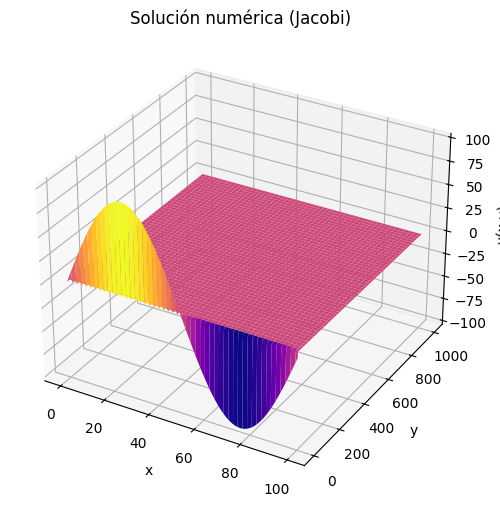

In [108]:
#@title Grafiquita de la solución numérica

# Parámetros
L = 100
u0 = 100
Nx = 100
Ny = 1000
dx = 1
Niter = 10

V = np.zeros((Nx, Ny))


for i in range(Nx):
    x = i * dx
    V[i,0] = u0 * np.sin(2*np.pi*x/L)

# Aplicando el método
for it in range(Niter):
    V_old = V.copy()
    for i in range(1, Nx-1):
        for j in range(1, Ny-1):
            V[i,j] = 0.25 * (
                V_old[i+1,j] + V_old[i-1,j] +
                V_old[i,j+1] + V_old[i,j-1]
            )

x = np.linspace(0, L, Nx)
y = np.linspace(0, Ny, Ny)
X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection='3d')

surf = ax.plot_surface(X, Y, V.T, cmap="plasma")

ax.set_title("Solución numérica (Jacobi)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("u(x,y)")

plt.show()

### Vemos que se parece bastante al método analítico en este caso a pesar de que el número de iteraciones sea solo de $Niter = 10$, como la función tiene una parte exponencial, esto genera que la solución converja más rápido y el método de Jacobi funcione.